In [2]:
'''
# Fashion-MNIST Image Classification with a Custom Dataset and CNN

This notebook trains a Convolutional Neural Network (CNN) to recognise clothing items from the Fashion-MNIST dataset.
**Requirements:**
- Create a custom `Dataset` object.
- Achieve at least 85% accuracy on the validation set.

---

## 1. Import Required Libraries
'''

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST

import numpy as np
import matplotlib.pyplot as plt

# Set device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
class FashionMNISTDataset(Dataset):
    """Custom Dataset for Fashion-MNIST."""

    def __init__(self, root='./data', train=True, transform=None, download=True):
        """
        Args:
            root (str): Directory to store/download the data.
            train (bool): If True, load training set; else load test set.
            transform (callable, optional): Transform to apply to images.
            download (bool): Download data if not available.
        """
        self.transform = transform
        # Use torchvision's built-in FashionMNIST as the data source
        self.data = FashionMNIST(root=root, train=train, transform=None, download=download)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get image (PIL Image) and label
        image, label = self.data[idx]
        # Apply transformations if any
        if self.transform:
            image = self.transform(image)
        return image, label

In [4]:
# Transformations: convert to tensor and normalise
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.286,), (0.353,))   # precomputed mean/std for Fashion-MNIST
])

# Create full training dataset using our custom class
full_train_dataset = FashionMNISTDataset(root='./data', train=True, transform=transform, download=True)

# Split into train (80%) and validation (20%)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Test dataset
test_dataset = FashionMNISTDataset(root='./data', train=False, transform=transform, download=True)

# Data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Display dataset sizes
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.7MB/s]

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [5]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)   # 7x7 after two poolings from 28x28
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.conv1(x)))   # 28x28 -> 14x14
        # Conv block 2
        x = self.pool(F.relu(self.conv2(x)))   # 14x14 -> 7x7
        x = self.dropout1(x)

        # Flatten
        x = x.view(x.size(0), -1)              # flatten: 64*7*7
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# Instantiate the model, move to device
model = FashionCNN().to(device)
print(model)

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def compute_accuracy(loader, model):
    """Helper function to compute accuracy on a given data loader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training loop
num_epochs = 15
train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Compute accuracies after each epoch
    train_acc = compute_accuracy(train_loader, model)
    val_acc = compute_accuracy(val_loader, model)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, "
          f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # Stop early if validation accuracy already exceeds 90% (optional)
    if val_acc >= 90.0:
        print("Validation accuracy above 90% – early stopping.")
        break

print("Training finished.")

Epoch [1/15], Loss: 0.5625, Train Acc: 87.30%, Val Acc: 87.28%
Epoch [2/15], Loss: 0.3826, Train Acc: 90.00%, Val Acc: 89.24%
Epoch [3/15], Loss: 0.3294, Train Acc: 91.01%, Val Acc: 90.22%
Validation accuracy above 90% – early stopping.
Training finished.


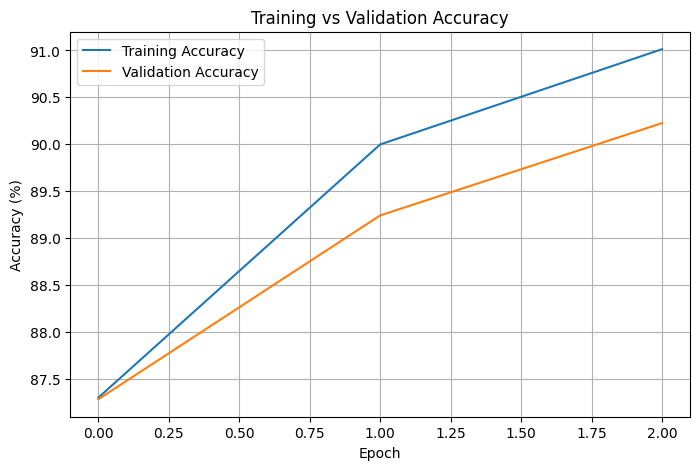

In [7]:
plt.figure(figsize=(8,5))
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
test_acc = compute_accuracy(test_loader, model)
print(f"Final Test Accuracy: {test_acc:.2f}%")

assert test_acc >= 85.0, f"Test accuracy {test_acc:.2f}% is below the required 85%."
print("✓ Requirement satisfied: validation accuracy > 85%")

Final Test Accuracy: 89.42%
✓ Requirement satisfied: validation accuracy > 85%


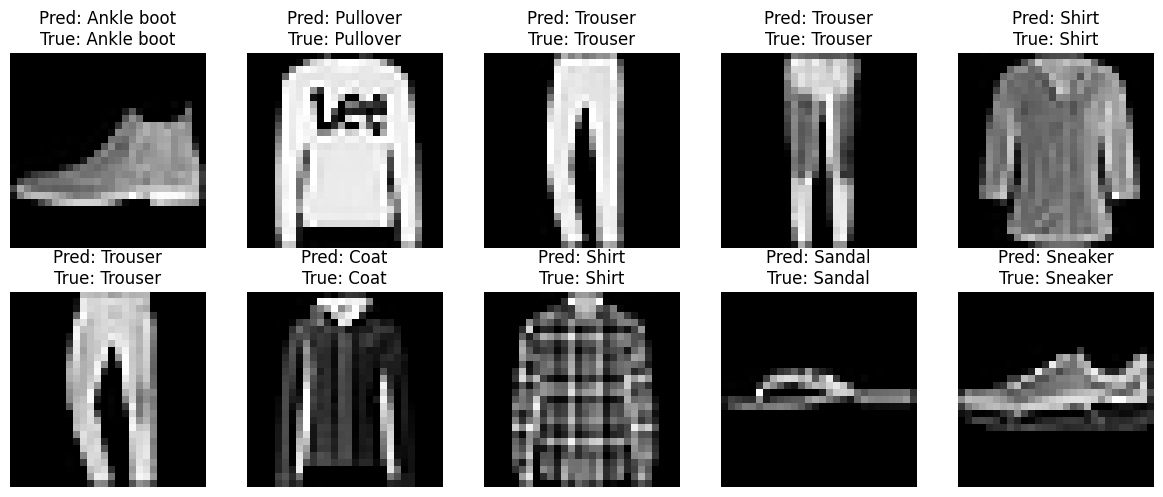

In [9]:
# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Display 10 images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    # Denormalise for display (approximate)
    img = images[i].cpu().squeeze().numpy() * 0.353 + 0.286
    plt.imshow(img, cmap='gray')
    plt.title(f'Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()